Codons ensemble quelques métriques pour évaluer les sorties d’un modèle de segmentation.  

<img src="./Assets/Picture1.png" style="max-width: 70%; height: auto; display: block; margin: 0 auto;" />


<img src='./Assets/Picture2.png' style="max-width: 70%; height: auto; display: block; margin: 0 auto;" />


Pour une classe donnée c , nous définissons les décomptes par pixels comme suit :

TP (vrais positifs) : prédiction c et étiquette réelle c .  
FP (faux positifs) : prédiction c mais l’étiquette réelle n’est pas c .  
FN (faux négatifs) : l’étiquette réelle est c mais prédiction autre chose que c .  
TN (vrais négatifs) : l’étiquette réelle n’est pas c et prédiction autre chose que c .  

La précision par classe est alors définie comme :  
(TP + TN) / (TP + TN + FP + FN)  

Dans une classification multi-classes, les TN pour chaque classe deviennent souvent si nombreux qu'ils peuvent rendre la précision trompeuse.  

En d'autres termes, lorsque vous calculez la précision pour une seule classe dans un problème multi-classes (par exemple, "est-ce un chat ?"), les vrais négatifs proviennent de toutes les autres classes combinées (chiens, oiseaux, poissons, etc.). Étant donné qu'il existe beaucoup de "non-chats", le décompte des TN peut facilement devenir une valeur très élevée, ce qui peut gonfler artificiellement le score de précision.  

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os


Exercice : Ajoutez le calcul de la précision par classe et de la précision globale à la fonction ci-dessous. Des indices sont insérés dans la base de code.  
N'hésitez pas à discuter avec votre agent GenIA préféré pour résoudre le problème.  

In [ ]:
def calculate_precision_recall_fscore_acc(label, pred, num_classes):

  """
    Calcule par classe la précision, le rappel et le F1-score ainsi que la précision globale.

    label: masque de vérité terrain HxL entier (alias annotation)
    pred:  masque de prédiction HxL entier
    num_classes: nombre de classes (les étiquettes de classe seraient 0..num_classes-1)

    Retourne:
        classes_precision, classes_recall, classes_fscore, <classes_accuracy>, <overall_accuracy>
        (chacun une liste de longueur num_classes)
  """
  classes_precision = []
  classes_recall = []
  classes_fscore = []
  classes_accuracy = []
  overall_accuracy = 0
  for c in range(num_classes):
      pred_c = (pred == c).astype(np.float32)
      true_c = (label == c).astype(np.float32)
      TP = np.sum(pred_c * true_c)
      FP = np.sum((pred_c - true_c) == 1)
      FN = np.sum((true_c - pred_c) == 1)
      # Astuce - TN signifie que les deux pred_c et true_c sont 0
     
      precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0
      recall = TP / (TP + FN) if (TP + FN) > 0 else 0.0
      if precision + recall > 0:
          fscore = 2 * (precision * recall) / (precision + recall)
      else:
          fscore = 0.0
      # Astuce - La précision de la classe c est définie comme (TP + TN) / (TP + TN + FP + FN)
      
      classes_precision.append(precision)
      classes_recall.append(recall)
      classes_fscore.append(fscore)
      # Astuce - garder une trace de la précision aussi
      
  # precision_gobale = Somme de tous les TP divisée par le nombre total de pixels dans le masque.
  return classes_precision, classes_recall, classes_fscore, classes_accuracy, overall_accuracy

In [3]:
def calculate_iou(label, pred, num_classes, nan_allowed=True):
    classes_ious = []
    for c in range(num_classes):
        pred_c = (pred == c).astype(np.float32)
        true_c = (label == c).astype(np.float32)
        iou_is_nan = False
        if nan_allowed:
            if true_c.sum() == 0 and pred_c.sum() == 0:
                iou_is_nan = True
        if iou_is_nan:
            classes_ious.append(np.nan)
        else:
            intersection = np.sum(pred_c * true_c)
            union = np.sum((pred_c + true_c) > 0)
            iou = (intersection + 1e-8) / (union + 1e-8)
            classes_ious.append(iou)
    return classes_ious

Exercice : Corrigez la fonction calculate_show_metrics afin qu’elle affiche également la précision par classe et les métriques de précision globale.

In [ ]:
def mask_colorizer(mask, class_color):
  mask = np.repeat(mask[..., None], 3, axis=2)
  colorized_mask = np.zeros(shape=(mask.shape[0], mask.shape[1], 3), dtype=np.uint8)

  for label, colour in class_color.items():
      colorized_mask = np.where(mask == label, colour, colorized_mask)

  return colorized_mask

def calculate_show_metrics(image, annotation, prediction, num_classes, nan_allowed=True, class_color=None):
    print('_______________Performance Metrics ______________')
    pr, re, f1, ac, all_ac = calculate_precision_recall_fscore_acc(annotation, prediction, num_classes)
    iou = calculate_iou(annotation, prediction, num_classes, nan_allowed=nan_allowed)
    print(f"IoU per class: {[float(f'{x:.2f}') for x in iou]}")
    print(f"Precision per class: {[float(f'{x:.2f}') for x in pr]}")
    print(f"Recall per class: {[float(f'{x:.2f}') for x in re]}")
    print(f"F1-score per class: {[float(f'{x:.2f}') for x in f1]}")
    # Astuce - Insérez votre code ici
    

    f, axarr = plt.subplots(1, 3, figsize=(30,30))
    axarr[0].title.set_text('Input image')
    axarr[1].title.set_text('Ground Truth Annotation')
    axarr[2].title.set_text('Predicted Mask')
    axarr[0].imshow(image)
    if class_color is None:
      axarr[1].imshow(annotation, vmin=0, vmax=num_classes)
      axarr[2].imshow(prediction, vmin=0, vmax=num_classes)
    else:
      axarr[1].imshow(mask_colorizer(annotation, class_color))
      axarr[2].imshow(mask_colorizer(prediction, class_color))
    for i in range(3):
        axarr[i].axis("off")
    plt.show()

    return pr, re, f1, iou, ac, all_ac

Si vous avez correctement réalisé les exercices précédents, vous devriez obtenir ces valeurs pour la précision par classe :

    Accuracy per class: [1.0, 0.98, 0.98, 0.99]
    Overall accuracy: 0.98

class 0: background shown by black color
class 1: shown by blue color
class 2: shown by green color
class 3: shown by yellow color
_______________Performance Metrics ______________
IoU per class: [1.0, 0.7, 0.0, 0.93]
Precision per class: [1.0, 0.76, 0.0, 0.95]
Recall per class: [1.0, 0.9, 0.0, 0.97]
F1-score per class: [1.0, 0.82, 0.0, 0.96]


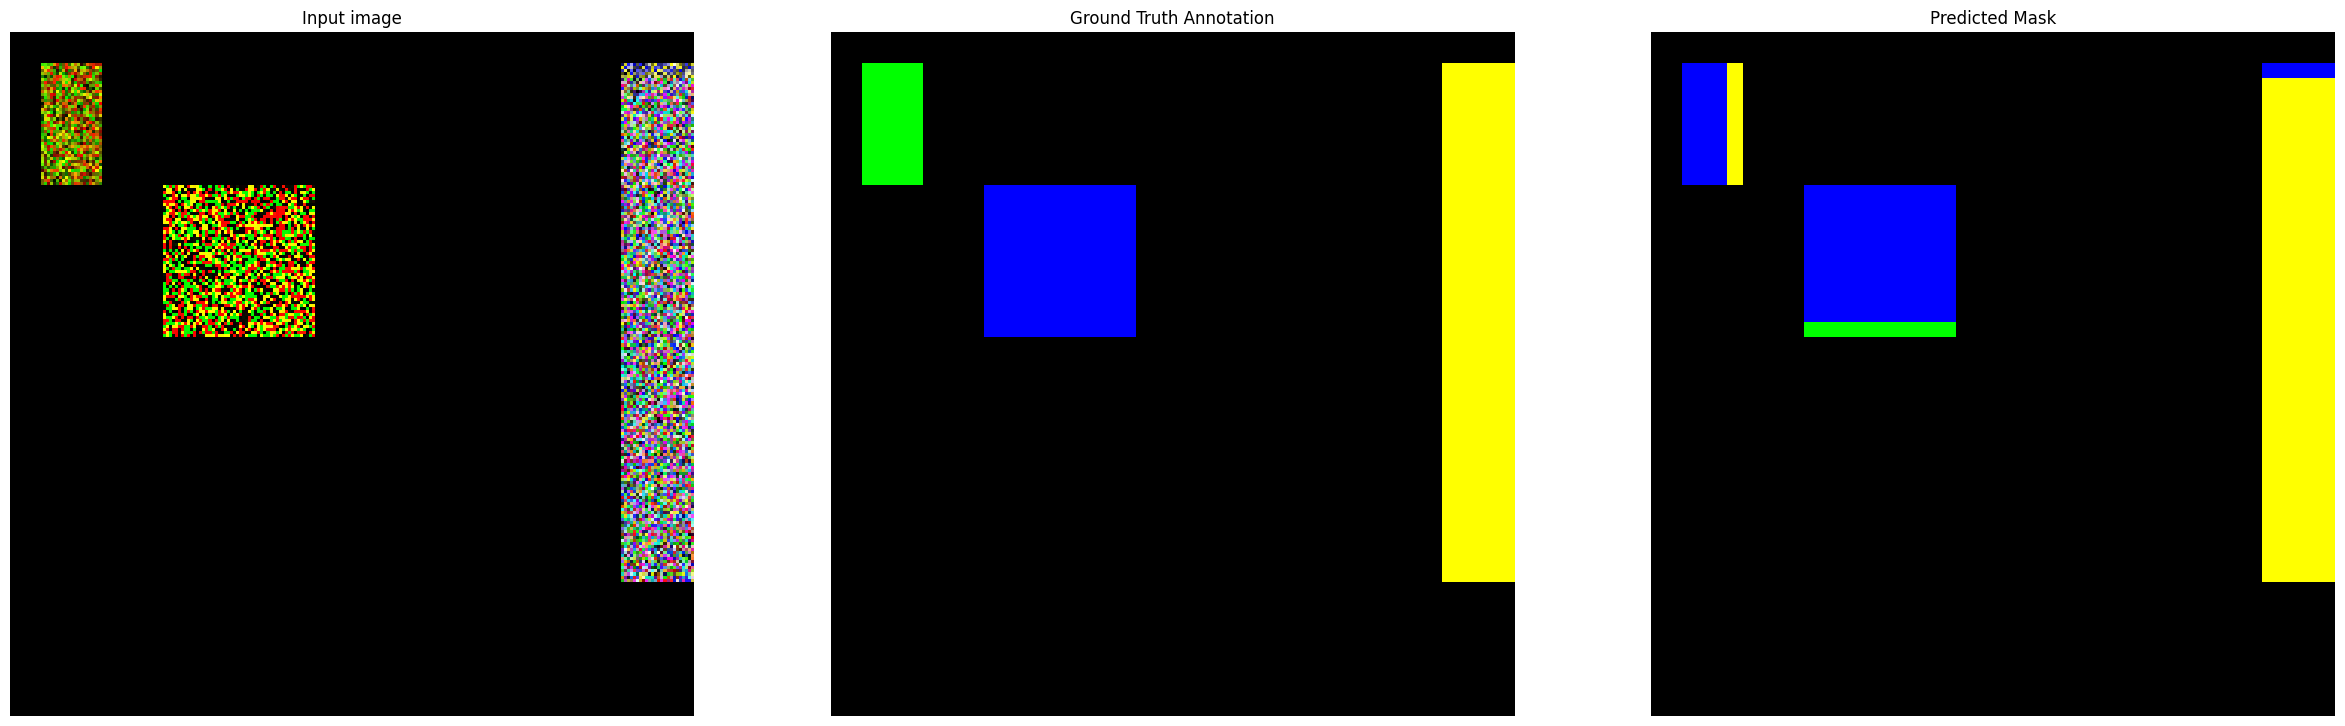

In [ ]:
def create_dummy_sample():
  cols = 224
  rows = 224
  num_channels = 3
  sample = {}
  dummy_imageg = np.zeros((rows, cols, num_channels)).astype(np.uint8)
  dummy_imageg[50:100, 50:100, 0:2] = np.random.randn(50, 50, 2) * 10

  dummy_imageg[10:50, 10:30, 0:2] = np.random.randn(40, 20, 2) * 199
  dummy_imageg[10:180, 200:224, :] = np.random.randn(170, 24, 3) * 73
  dummy_imageg[10:15, 200:224, 0:2] = np.random.randn(5, 24, 1) * 73
  sample['img_input'] = dummy_imageg
  dummy_imageg = np.zeros((rows, cols)).astype(np.int16)
  dummy_imageg[50:100, 50:100] = 1
  dummy_imageg[10:50, 10:30] = 2
  dummy_imageg[10:180, 200:224] = 3
  sample['label_mask'] = dummy_imageg
  dummy_imageg = np.zeros((rows, cols)).astype(np.int16)
  dummy_imageg[50:95, 50:100] = 1  # vrai positif pour la classe 1
  dummy_imageg[95:100, 50:100] = 2  # faux négatif pour la classe 1 et faux positif pour la classe 2
  dummy_imageg[10:50, 10:25] = 1  # faux positif pour la classe 1 et faux négatif pour la classe 2
  dummy_imageg[10:50, 25:30] = 3  # faux positif pour la classe 3 et faux négatif pour la classe 2
  dummy_imageg[15:180, 200:224] = 3 # vrai positif pour la classe 3
  dummy_imageg[10:15, 200:224] = 1 # faux positif pour la classe 1 et faux négatif pour la classe 3
  sample['pred_mask'] = dummy_imageg
  print('class 0: background shown by black color')
  print('class 1: shown by blue color')
  print('class 2: shown by green color')
  print('class 3: shown by yellow color')
  return sample

sample = create_dummy_sample()
_ = calculate_show_metrics(sample['img_input'], sample['label_mask'], sample['pred_mask'], 4,
                        nan_allowed=True, class_color={0:[0, 0, 0], 1:[0, 0, 255], 2:[0, 255, 0], 3:[255, 255, 0]})



Voyons maintenant ce qui se passe avec un exemple réel.

J’ai une image RVB d’entrée disponible à ce lien : 'https://drive.google.com/uc?export=download&id=1oCVtJWMX7t51hQAE42Ih_UUeiLgPWYWg'  
Pour cette image, j’ai un masque annoté manuellement (appelé aussi vérité terrain) des zones brûlées, disponible à ce lien : 'https://drive.google.com/uc?export=download&id=16HpPwv3KCHtg62pPtldMrM182wZRiVJq'  
J’ai entraîné un modèle d’apprentissage profond pour la segmentation des zones brûlées et je l’ai appliqué sur l’image, ce qui a produit ce masque prédit : 'https://drive.google.com/uc?export=download&id=14zTdZhiKLEEIyeGUTn-SAtMOt1X18lvC'  

Dans les masques d’annotation et de prédiction, les pixels de valeur 0 correspondent à l’arrière-plan (non brûlé) et ceux de valeur 1 correspondent à la classe des zones brûlées.

Avec ou sans l’aide d’un agent d’IA et en s’appuyant sur les fonctions que nous avons écrites plus tôt, calculons la performance (bonne ou mauvaise) de mon modèle sur cette image en particulier.


Source des données utiisées dans cet exemple: https://huggingface.co/datasets/ibm-nasa-geospatial/hls_burn_scars

Indice :  

Si ce notebook était exécuté localement sur votre machine et que l'image se trouvait, par exemple, dans "C:/myimage.tif", alors vous pourriez la lire en utilisant la fonction d'image Pillow comme suit :  

    image = Image.open("C:/myimage.tif")

Cependant, comme l'image est située sur un Google Drive auquel nous avons accès via une URL, une étape supplémentaire est nécessaire pour demander le contenu de l'URL (c'est-à-dire notre image) :  


    response = requests.get(url)
    response.raise_for_status()
    image = Image.open(BytesIO(response.content))



Si vous avez complété l'exercice correctement, vous devriez voir des résutats comme cet exemple:  

<img src="./Assets/Example_Results.png" style="max-width: 70%; height: auto; display: block; margin: 0 auto;" />

In [ ]:
from PIL import Image
import requests
from io import BytesIO

def read_image_url(url):
  response = requests.get(url)
  response.raise_for_status()
  image = Image.open(BytesIO(response.content))
  return image

# Astuce - Insérez votre code ici

**Ouvrir et exécuter ce notebook sur votre machine**  
Si vous souhaitez essayer ce notebook à partir de votre machine locale en tant que notebook Jupyter, faites-en une copie sur votre Google Drive (à partir du menu Fichier de cette page), puis téléchargez le fichier `.ipynb` copié depuis votre Google Drive vers votre machine.  
Ensuite, téléchargez également le fichier de dépendances disponible dans ce dépôt GitHub [requirements,txt](../requirements.txt).  

Suivez ces étapes pour installer un environnement Python et exécuter le notebook :  

📌 **Étape 1 — Installer Anaconda** (*à faire une seule fois*)  
Accédez à :  
[https://www.anaconda.com/download](https://www.anaconda.com/download)  
Téléchargez la version correspondant à votre système d'exploitation (Windows, macOS, Linux).  
Installez-le en utilisant les options par défaut :  
Laissez l’option **“Add to PATH” (Ajouter à PATH)** non cochée.  
Vous aurez maintenant un programme appelé Anaconda Prompt (Windows) ou Terminal (macOS/Linux).  

📌 **Étape 2 — Ouvrir Anaconda Prompt / Terminal**  
- Windows : recherchez "Anaconda Prompt" dans le menu Démarrer.  
- macOS/Linux : ouvrez Terminal.  
Vous devrez taper toutes les commandes ci-dessous dans cette fenêtre.  

📌 **Étape 3 — Créer un nouvel environnement avec la bonne version de Python**  
Le tutoriel d'aujourd'hui utilise Python 3.12.  
Tapez ceci dans Anaconda Prompt :  
    ```
    conda create -n tutorial python=3.12  
    ```  
Appuyez sur **Y** lorsqu'on vous le demande, puis attendez que les installations soient terminées.  

Note : **"tutorial"** est simplement un nom donné à cet environnement conda. Vous pouvez le nommer autrement.  

📌 **Étape 4 — Activer l'environnement**  
    ```
    conda activate tutorial  
    ```  
Vous saurez que cela a fonctionné car l'invite affichera quelque chose comme :  
    (tutorial) C:\Users\vous>  

📌 **Étape 5 — Installer tous les packages requis à partir de requirements.txt**  
Disons que le fichier `requirements.txt` se trouve dans le dossier : C:\Users\vous\Downloads.  
Dans l'Anaconda Prompt (l'environnement doit être actif), naviguez d’abord vers ce dossier :  
    ``` 
    cd C:\Users\vous\Downloads  
    ```  
Ensuite, installez les dépendances :  
    ```  
    pip install -r requirements.txt  
    ```  

📌 **Étape 6 — Démarrer Jupyter Notebook**  
Accédez au dossier dans lequel vous avez copié le fichier `.ipynb`, puis exécutez la commande :  
    ```  
    jupyter notebook  
    ```  
Un navigateur web s'ouvrira automatiquement.  

📌 **Étape 7 — Ouvrir votre fichier `.ipynb`**  
Cliquez sur le notebook pour l'ouvrir.  
Avant de l'exécuter, assurez-vous :  
    ✔ **de sélectionner le bon kernel**  
    En haut à droite (Notebook) :  
    Kernel → Change Kernel → Python (tutorial)  
Ce paramètre devrait être défini par défaut, mais le valider garantit que le notebook utilise l'environnement que vous venez de créer.  

📌 **À l’avenir**, si vous souhaitez travailler avec ce notebook, vous devrez simplement activer votre environnement avec la commande :  
    ```  
    conda activate tutorial   
    ```  

Puis exécuter Jupyter Notebook :  
    ``` 
    jupyter notebook   
    ```  
Enfin, ouvrez votre fichier notebook sur lequel vous souhaitez travailler !  

